CELL 1 — Load the Dataset

In [2]:
# Libraries are pre-built tools that save us from writing everything ourselves

import pandas as pd          # for loading and working with data (like Excel in Python)
import numpy as np           # for math/number operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns        # nicer-looking charts built on top of matplotlib
import warnings
warnings.filterwarnings('ignore')  # hide minor warnings so output looks cleaner

print("Libraries loaded!")

Libraries loaded!


CELL 2 — Load the Dataset

In [3]:
# pd.read_csv() reads a CSV file and stores it as a DataFrame (like a table)
df = pd.read_csv(r'c:\Users\teybo\OneDrive\Documents\BMDS3003-Data-Science-Telcom-Customer-Churn-\Telco_Cusomer_Churn.csv')

# .shape tells you (rows, columns)
print("Shape:", df.shape)

# .head() shows the first 5 rows
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


CELL 3 — Understand Data

In [6]:
# .info() shows column names, data types, and non-null counts
df.info()

# .describe() gives statistics for number columns (mean, min, max, etc.)
df.describe()

# Check for missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Cell 4 - Explore the Target Column (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


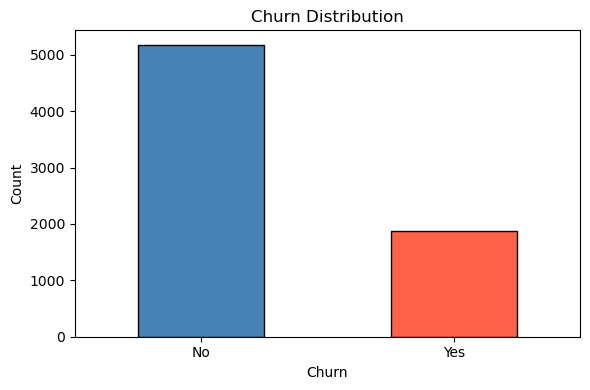

In [7]:
# Count how many Yes/No in the Churn column
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)  # as percentages

# Visualise it
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Cell 5 - Explore Key Features (EDA)

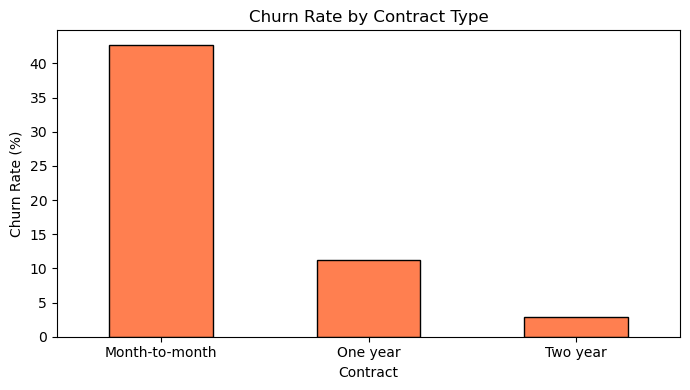

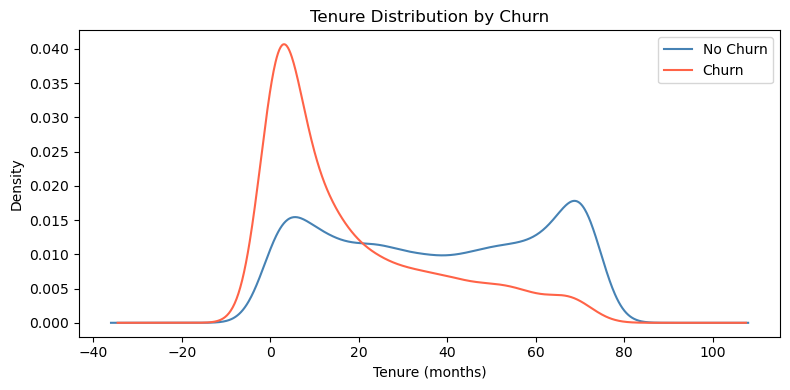

In [8]:
# Churn rate by Contract type — one of the most important features
plt.figure(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribution of tenure (how long customers stay) vs Churn
plt.figure(figsize=(8, 4))
df[df['Churn'] == 'No']['tenure'].plot(kind='kde', label='No Churn', color='steelblue')
df[df['Churn'] == 'Yes']['tenure'].plot(kind='kde', label='Churn', color='tomato')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.legend()
plt.tight_layout()
plt.show()

Cell 7 - Fix the TotalCharges

In [9]:
# TotalCharges is stored as text (object), convert it to number
# Any blank/empty string becomes NaN automatically
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many NaN appeared
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# These 11 rows are new customers (tenure = 0, never been billed)
# So we fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("After fix:", df["TotalCharges"].isnull().sum(), "missing values")
print("✅ TotalCharges fixed!")

Missing TotalCharges: 11
After fix: 0 missing values
✅ TotalCharges fixed!


Cell 8 - Drop customerID

In [10]:
# customerID is just a unique ID number, it doesn't help predict churn
# (worse — for a linear model it would even be misread as a giant numeric feature)
df = df.drop(columns=["customerID"])

print("New shape:", df.shape)
print("✅ customerID removed!")

New shape: (7043, 20)
✅ customerID removed!


Cell 9 - Encode Text Columns

In [11]:
# Binary columns (only 2 possible values) -> simple 1/0 mapping
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

print("✅ Binary columns encoded!")

# Multi-value columns -> One-Hot Encoding
# This creates a new 0/1 column for each possible value. For Logistic Regression
# specifically this matters even more than for KNN: the model reads a raw integer
# category (e.g. DSL=0, Fiber=1, None=2) as an ORDERED, evenly-spaced quantity,
# which would attach a meaningless, misleading coefficient to it. One-hot avoids that.
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
print("✅ Text columns encoded!")

✅ Binary columns encoded!
Shape after one-hot encoding: (7043, 31)
✅ Text columns encoded!


Cell 10 - Train / Test Split First, Then Scale

Why order matters: if we scale (fit StandardScaler) on the whole dataset and then split into train/test, the scaler has already "seen" the test rows when it computed its mean/std. That's data leakage - the test set is supposed to be completely untouched until evaluation. 

So we split first, fit the scaler on X_train only, then use that same fitted scaler to transform X_test. This matches shared/preporcessing.py, which the other members' scripts rely on.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = all columns except Churn (the inputs), y = Churn (what we predict)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Split BEFORE scaling — stratify=y keeps the same 73/27 churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the scaler on TRAIN ONLY, then apply it to both — no leakage
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Features:      {X_train.shape[1]} columns")
print("✅ Split done, scaler fit on train only!")


Training set:  5634 rows
Test set:      1409 rows
Features:      30 columns
✅ Split done, scaler fit on train only!


Cell 11 - What does Random Forest Do? 

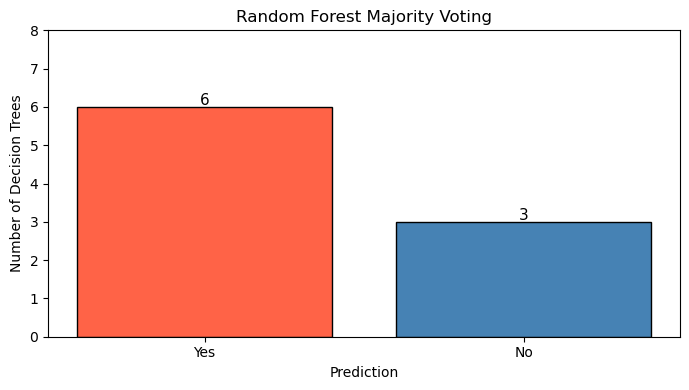

Predictions from each tree:
Tree 1: Yes
Tree 2: Yes
Tree 3: No
Tree 4: Yes
Tree 5: Yes
Tree 6: No
Tree 7: Yes
Tree 8: No
Tree 9: Yes

Votes
Counter({'Yes': 6, 'No': 3})

Final Prediction = Yes


In [14]:
import matplotlib.pyplot as plt
from collections import Counter

# Example predictions from 9 decision trees
tree_predictions = [
    "Yes",
    "Yes",
    "No",
    "Yes",
    "Yes",
    "No",
    "Yes",
    "No",
    "Yes"
]

# Count the votes
vote_counts = Counter(tree_predictions)

# Plot
plt.figure(figsize=(7,4))

bars = plt.bar(
    vote_counts.keys(),
    vote_counts.values(),
    color=["tomato", "steelblue"],
    edgecolor="black"
)

# Display vote count above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.05,
        int(bar.get_height()),
        ha='center',
        fontsize=11
    )

plt.title("Random Forest Majority Voting")
plt.xlabel("Prediction")
plt.ylabel("Number of Decision Trees")
plt.ylim(0, max(vote_counts.values())+2)

plt.tight_layout()
plt.show()

print("Predictions from each tree:")
for i, prediction in enumerate(tree_predictions, start=1):
    print(f"Tree {i}: {prediction}")

print("\nVotes")
print(vote_counts)

print(f"\nFinal Prediction = {vote_counts.most_common(1)[0][0]}")